In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("b/customer_data.csv")

In [4]:
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [5]:
df.shape

(7043, 21)

In [6]:
df.isnull().sum().sort_values(ascending=False)

TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numeric_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [9]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    
    percent_outliers = (len(outliers) / len(df[col])) * 100
    
    print(f"{col:<25} : {percent_outliers:6.2f}% outliers")

SeniorCitizen             :  16.21% outliers
tenure                    :   0.00% outliers
MonthlyCharges            :   0.00% outliers
TotalCharges              :   0.00% outliers


col unique values: [0 1]


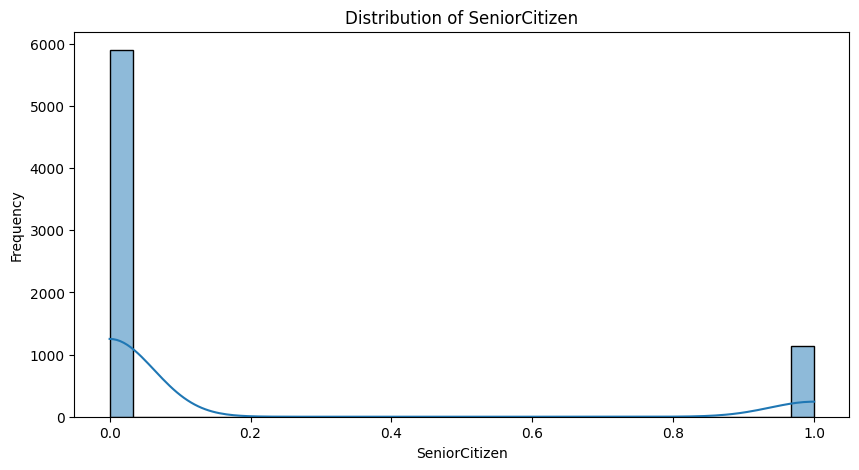

In [10]:
print("col unique values:", df['SeniorCitizen'].unique())
plt.figure(figsize=(10,5))
sns.histplot(df['SeniorCitizen'], kde=True, bins=30)
plt.title("Distribution of SeniorCitizen")
plt.xlabel('SeniorCitizen')
plt.ylabel("Frequency")
plt.show()

col unique values: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]


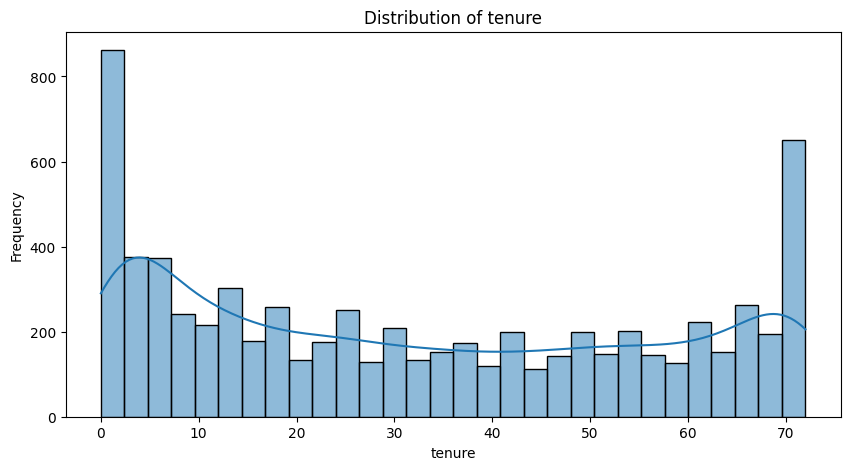

In [39]:
print("col unique values:", df['tenure'].unique())
plt.figure(figsize=(10,5))
sns.histplot(df['tenure'], kde=True, bins=30)
plt.title("Distribution of tenure")
plt.xlabel('tenure')
plt.ylabel("Frequency")
plt.show()

col unique values: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]


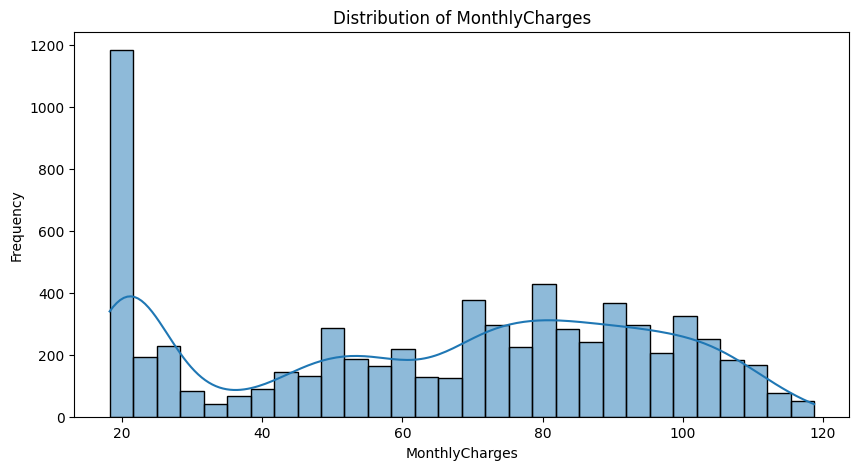

In [40]:
print("col unique values:", df['MonthlyCharges'].unique())
plt.figure(figsize=(10,5))
sns.histplot(df['MonthlyCharges'], kde=True, bins=30)
plt.title("Distribution of MonthlyCharges")
plt.xlabel('MonthlyCharges')
plt.ylabel("Frequency")
plt.show()

col unique values: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]


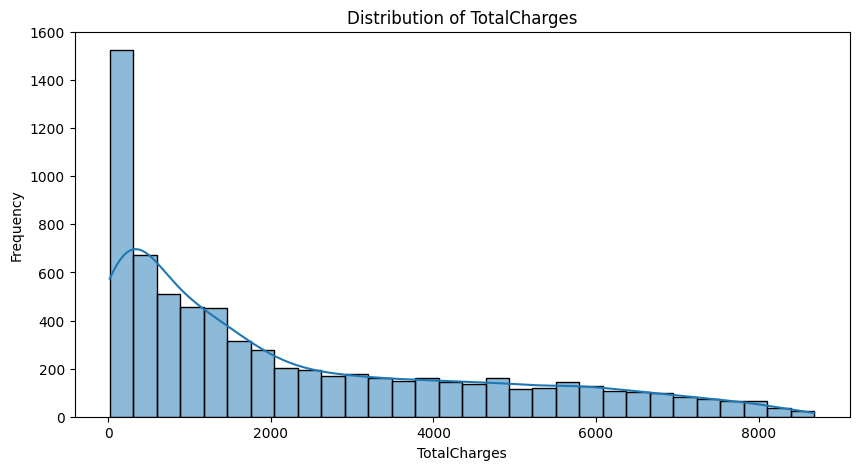

In [41]:
print("col unique values:", df['TotalCharges'].unique())
plt.figure(figsize=(10,5))
sns.histplot(df['TotalCharges'], kde=True, bins=30)
plt.title("Distribution of TotalCharges")
plt.xlabel('TotalCharges')
plt.ylabel("Frequency")
plt.show()

In [42]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn',
               'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
               'StreamingTV','StreamingMovies','MultipleLines']

for col in binary_cols:
    df[col] = df[col].map({'Yes':1,'No':0})

In [43]:
df = pd.get_dummies(df, columns=['gender','InternetService','Contract','PaymentMethod'], drop_first=True)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          6361 non-null   float64
 7   OnlineSecurity                         5517 non-null   float64
 8   OnlineBackup                           5517 non-null   float64
 9   DeviceProtection                       5517 non-null   float64
 10  TechSupport                            5517 non-null   float64
 11  Stre

In [60]:
for col in df.columns:
    print(f"Column: {col}")
    print(f"Unique values ({df[col].nunique()}): {df[col].unique()}\n")

Column: gender
Unique values (2): ['Female' 'Male']

Column: SeniorCitizen
Unique values (2): [0 1]

Column: Partner
Unique values (2): ['Yes' 'No']

Column: Dependents
Unique values (2): ['No' 'Yes']

Column: tenure
Unique values (73): [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

Column: PhoneService
Unique values (2): ['No' 'Yes']

Column: MultipleLines
Unique values (3): ['No phone service' 'No' 'Yes']

Column: InternetService
Unique values (3): ['DSL' 'Fiber optic' 'No']

Column: OnlineSecurity
Unique values (3): ['No' 'Yes' 'No internet service']

Column: OnlineBackup
Unique values (3): ['Yes' 'No' 'No internet service']

Column: DeviceProtection
Unique values (3): ['No' 'Yes' 'No internet service']

Column: TechSupport
Unique values (3): ['No' 'Yes' 'No internet service']

Column: StreamingTV
Unique val

In [59]:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].value_counts(dropna=False))  # NaN values bhi show honge
    print("\n" + "-"*50 + "\n")


Column: gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

--------------------------------------------------

Column: SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

--------------------------------------------------

Column: Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--------------------------------------------------

Column: Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--------------------------------------------------

Column: tenure
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

--------------------------------------------------

Column: PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--------------------------------------------------

Column: MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Nam

In [58]:
addon_cols = ['MultipleLines','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

df[addon_cols] = df[addon_cols].fillna(0)
